# Task 1: Exploring and Visualizing the Iris Dataset

____________________________________

## Problem Statement

The goal of this task is to understand how to load, summarize, and visualize a real dataset using Python.
We use the famous Iris Dataset, which contains measurements of 150 flowers across 3 species: Setosa,
Versicolor, and Virginica. Each flower has 4 measurements: sepal length, sepal width, petal length, petal
width.

### Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
print("Libraries imported successfully!")

Libraries imported successfully!


### Step 2: Load the Dataset

In [2]:
df = sns.load_dataset('iris')
print("First 5 rows:")
df.head()

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Step 3: Dataset Understanding and Description

In [3]:
# Shape: (rows, columns)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Data types:")
print(df.dtypes)
# Statistical summary
df.describe()
# Count per species
print(df['species'].value_counts())
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


### Step 4: Data Cleaning and Preparation

In [4]:
# Check for duplicates
print("Duplicates:", df.duplicated().sum())
# Rename columns for clarity
df.columns = ['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width','Species']
print("Updated columns:", list(df.columns))

Duplicates: 1
Updated columns: ['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width', 'Species']


### Step 5: Exploratory Data Analysis (EDA) with Graphs

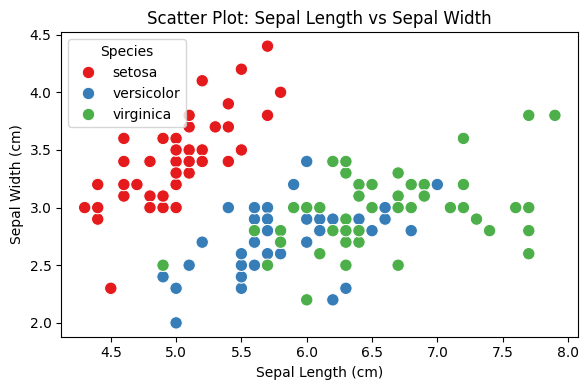

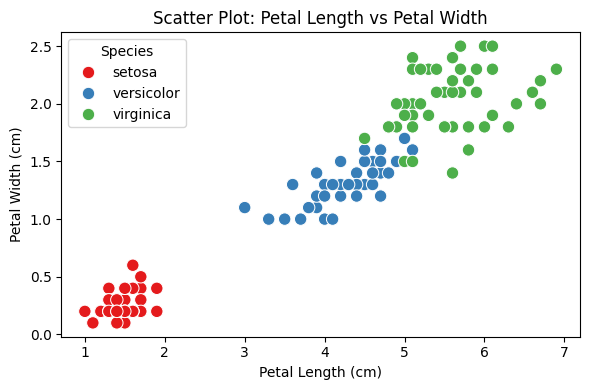

In [8]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Sepal_Length', y='Sepal_Width',
hue='Species', palette='Set1', s=80)
plt.title('Scatter Plot: Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.savefig('scatter_sepal.png', dpi=150)
plt.show()
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Petal_Length', y='Petal_Width',
hue='Species', palette='Set1', s=80)
plt.title('Scatter Plot: Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.savefig('scatter_petal.png', dpi=150)
plt.show()

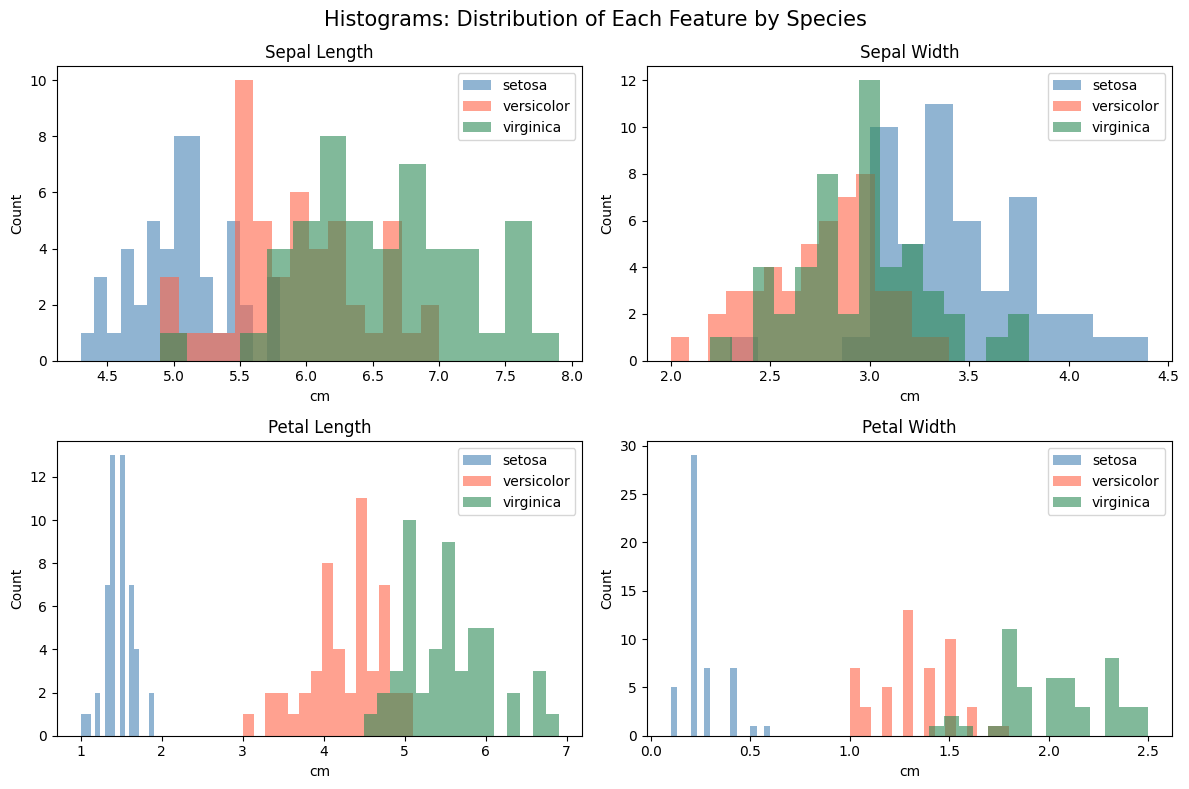

In [10]:
features = ['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width']
colors_list = ['steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Histograms: Distribution of Each Feature by Species', fontsize=15)

for i, feature in enumerate(features):

    ax = axes[i // 2][i % 2]

    for species, color in zip(df['Species'].unique(), colors_list):

        subset = df[df['Species'] == species]

        ax.hist(
            subset[feature],
            bins=15,
            alpha=0.6,
            label=species,
            color=color
        )

    ax.set_title(feature.replace('_', ' '))
    ax.set_xlabel('cm')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('histograms.png', dpi=150)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_18828\1845046036.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y=feature, palette='Set2', ax=ax)
C:\Users\admin\AppData\Local\Temp\ipykernel_18828\1845046036.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y=feature, palette='Set2', ax=ax)
C:\Users\admin\AppData\Local\Temp\ipykernel_18828\1845046036.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y=feature, palette='Set2', ax=ax)
C:\Users\admin\AppData\Local\Temp\ipyker

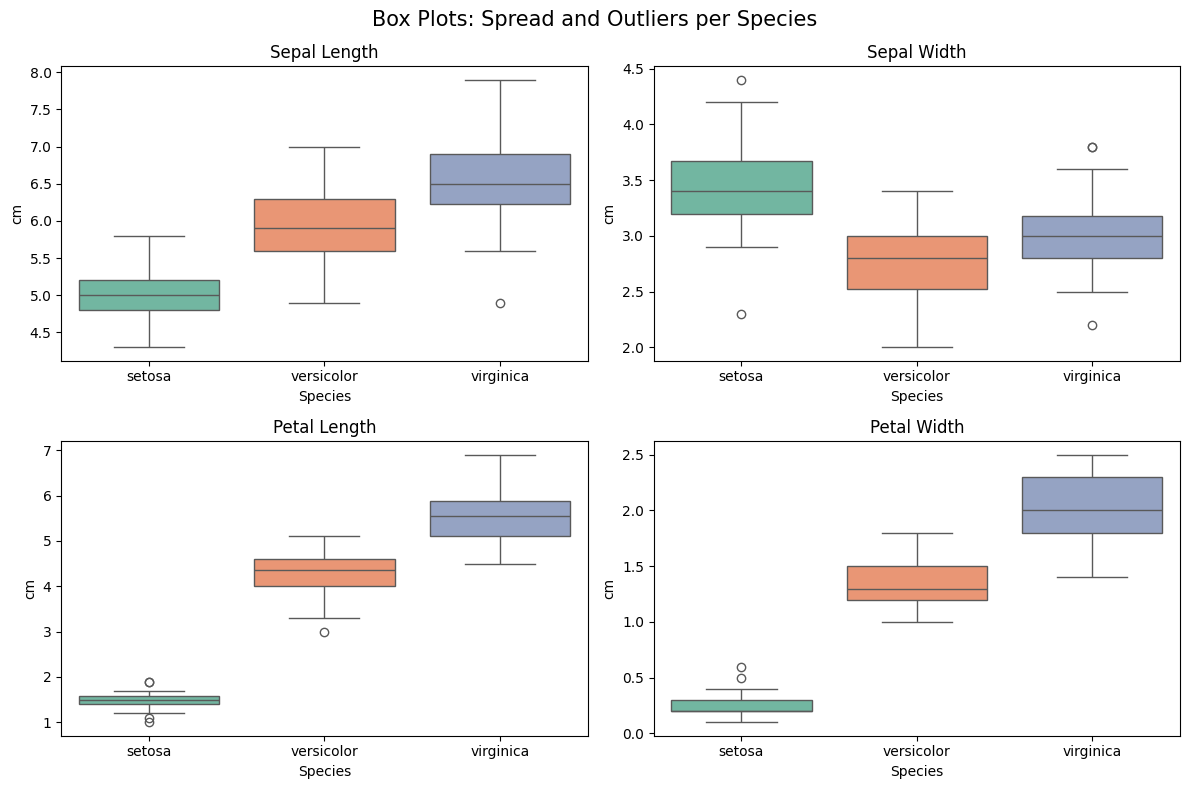

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

fig.suptitle('Box Plots: Spread and Outliers per Species', fontsize=15)

for i, feature in enumerate(features):

    ax = axes[i // 2][i % 2]
    sns.boxplot(data=df, x='Species', y=feature, palette='Set2', ax=ax)
    ax.set_title(feature.replace('_', ' '))
    ax.set_xlabel('Species')
    ax.set_ylabel('cm')

plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()

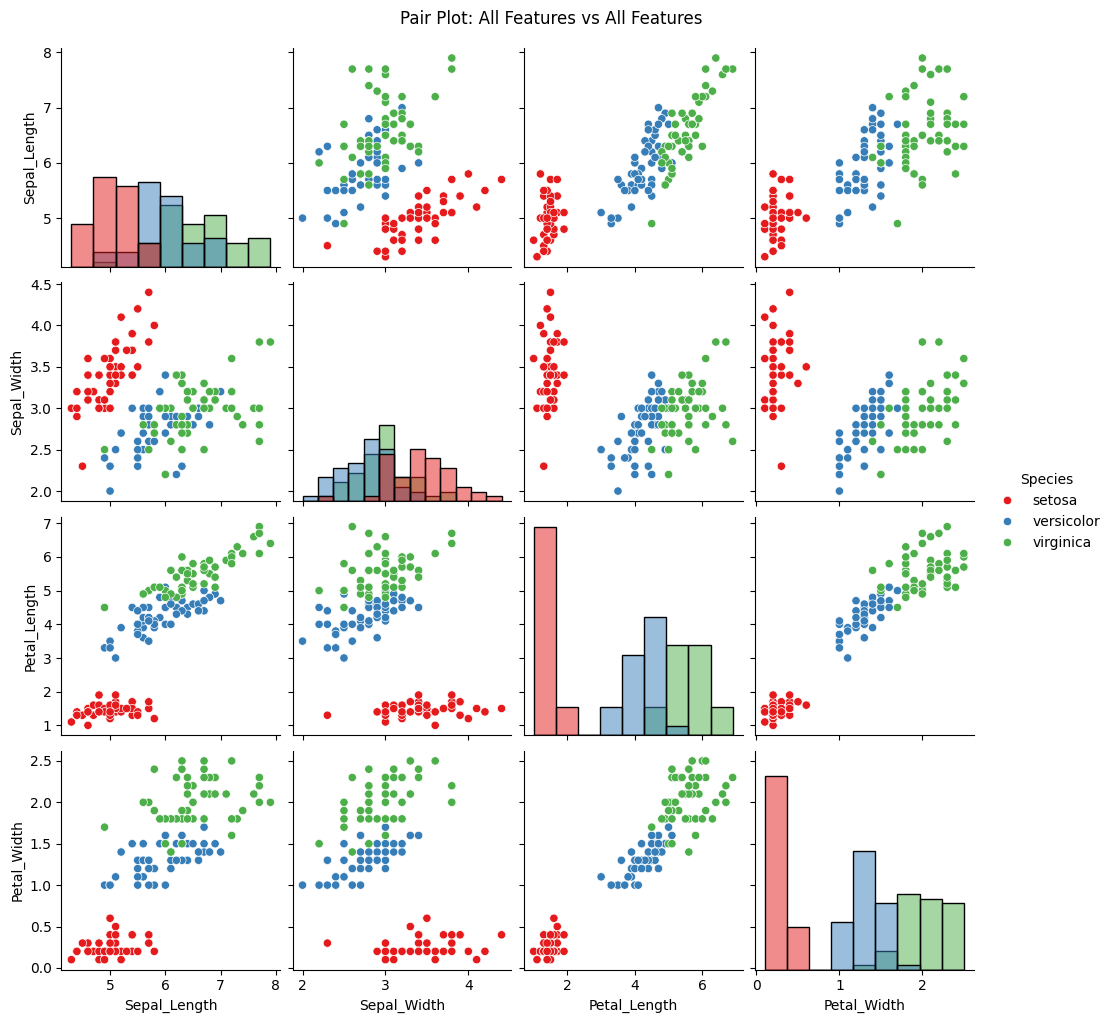

In [12]:
sns.pairplot(df, hue='Species', palette='Set1', diag_kind='hist')
plt.suptitle('Pair Plot: All Features vs All Features', y=1.02)
plt.savefig('pairplot.png', dpi=150)
plt.show()

### Conclusion — Key Insights

• **Dataset:** 150 flowers, 4 numerical features, 3 species (50 samples each — perfectly balanced).

• **No missing values were found** — the dataset is clean.

• **Setosa** is the most distinct species; it is easily separated from Versicolor and Virginica.

• **Petal Length and Petal Width** are the most useful features for distinguishing species.

• **Sepal Width** has a few outliers but they are not extreme.

• These insights suggest a machine learning model using petal features would achieve high accuracy.